In [9]:
from parsing_library import *
import os

In [1]:
1+1

2

In [2]:

def calculate_rmse_per_size(data_dir, saved_fits_dir, inference_method, sizes, D):

    rmse_scores = {}

    for data_id in range(1, 11):
     
        data_path = os.path.join(data_dir, f"{data_id}.json")
        with open(data_path) as f:
            data = json.load(f)
        
        true_theta = np.array(data['theta'])
        vocabulary = data['vocabulary']

        for size in sizes:
            fit = load_fit_by_size(size, os.path.join(saved_fits_dir, str(data_id)))

            if fit is None:
                continue

            if inference_method == 'hmc':
                estimated_word_vectors = fit['word_vectors']
                estimated_context_vectors = fit['context_vectors']
            elif inference_method == 'vi':
                estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_vi(fit.variational_sample_pd, vocabulary, D=D)
            elif inference_method in ('map', 'laplace'):
                estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_vi(fit.optimized_params_pd, vocabulary, D=D)
            elif inference_method == 'gibbs':
                filepath = os.path.join(saved_fits_dir, str(data_id), f'gibbs-samples-N-{size}.csv')
                estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_gibbs(filepath, vocabulary)

            num_samples = estimated_word_vectors.shape[2] if inference_method != 'map' else 1

            # Combine and reshape theta samples
            theta_combined = np.concatenate((estimated_word_vectors, estimated_context_vectors), axis=0)
            theta_samples = np.moveaxis(theta_combined, 2, 0)

            # Calculate RMSE
            rmse = calculate_rmse(theta_samples, true_theta, vocabulary)

            if size not in rmse_scores:
                rmse_scores[size] = []
            rmse_scores[size].append(rmse)

            #print(f"Dataset: {data_id}, Size: {size}, RMSE: {rmse}")

    return rmse_scores

def average_rmse_across_datasets(data_dir, base_dir, inference_method, sizes, D):
    rmse_scores_per_size = calculate_rmse_per_size(data_dir, base_dir, inference_method, sizes,D)
    average_rmse_scores = [np.mean(rmse_scores_per_size[size]) for size in sizes if size in rmse_scores_per_size]
    return average_rmse_scores


In [3]:
data_dir = "../../data/ten_V100K5"
base_dir = "../../results_ten_V100K5/nofix/hmc/"
inference_method = 'hmc'
sizes = [1000, 2000 ,5000, 10000, 20000, 50000, 100000, 500000, 1000000]
D = 5

average_rmse_hmc = average_rmse_across_datasets(data_dir, base_dir, inference_method, sizes,D)


KeyboardInterrupt: 

In [36]:
average_rmse_hmc

[0.10564655901765577,
 0.10542132156917491,
 0.10456250142874086,
 0.10163034957702455,
 0.09124758979340436,
 0.0649604271143221,
 0.04710005721240507,
 0.021292371624796854,
 0.015186997865457411]

In [7]:
data_dir = "../../data/ten_V100K5"
base_dir = "../../results_ten_V100K5/nofix/vi/"
inference_method = 'vi'
sizes = [1000, 2000 ,5000, 10000, 20000, 50000, 100000, 500000, 1000000]

average_rmse_vi= average_rmse_across_datasets(data_dir, base_dir, inference_method, sizes, D=5)


In [27]:
average_rmse_vi

[0.10593707661705243,
 0.10595060088885326,
 0.10592231381236832,
 0.1040668383365188,
 0.09486547160560765,
 0.0685526664221704,
 0.05114671140016983,
 0.026576777792448734,
 0.020654313360086177]

In [10]:
data_dir = "../../data/ten_V100K5"
base_dir = "../../results_ten_V100K5/nofix/map/"
inference_method = 'map'
sizes = [1000, 2000 ,5000, 10000, 20000, 50000, 100000, 500000, 1000000]

average_rmse_map= average_rmse_across_datasets(data_dir, base_dir, inference_method, sizes, D=5)


In [11]:
average_rmse_map

[0.10585412070178038,
 0.10585412062085524,
 0.11501808122554828,
 0.1246448120245008,
 0.10805825311091984,
 0.068891183966794,
 0.048415311937879485,
 0.021413799904862613,
 0.015230376341345952]

In [5]:
def plot_rmse(sizes, average_rmse_scores):
    """
    Plot the average RMSE scores.

    Args:
        sizes (list): List of sizes for which RMSE was calculated.
        average_rmse_scores (list): Average RMSE scores per size.
        base_dir (str): Base directory for the experiment (used in the title).
    """
    plt.figure(figsize=(10, 6))
    plt.plot(sizes, average_rmse_scores, marker='o')
    plt.xlabel('Data Size')
    plt.ylabel('RMSE')
    plt.grid(True)
    plt.show()

plot_rmse(sizes, average_rmse_vi)

NameError: name 'average_rmse_vi' is not defined

In [3]:
# GIBBS STUFF

import pandas as pd
gibbs = pd.read_csv('coverage.csv')


In [22]:
gibbs.head()

,dataset_ix,N,K,V,ci-90-coverage,RMSE,RMSE_normalized
0,1,1000,5,100,0.8971,0.105738,0.998903
1,2,1000,5,100,0.8960,0.105641,0.997990
2,3,1000,5,100,0.8977,0.105749,0.999011
3,4,1000,5,100,0.8961,0.105775,0.999256
4,5,1000,5,100,0.8975,0.105675,0.998308


In [25]:

gibbs_rmse = []
for VK, df in gibbs.groupby(['V','K']):
    print(VK)
    print(df['N'].value_counts())
    if VK == (100, 5):
        print('hey')
        gibbs_rmse = df.groupby('N')['RMSE'].apply(np.mean)
        



(100, 5)
N
1000      10
2000      10
5000      10
10000     10
20000     10
50000     10
100000    10
500000     1
Name: count, dtype: int64
hey
(200, 10)
N
1000       9
2000       9
5000       9
10000      9
20000      9
50000      9
100000     9
500000     1
1000000    1
Name: count, dtype: int64


In [3]:
# GIBBS STUFF

import pandas as pd
import numpy as np
gibbs = pd.read_csv('coverage-gooby.csv')


gibbs_rmse = []
for VK, df in gibbs.groupby(['V','K']):
    print(VK)
    print(df['N'].value_counts())
    if VK == (100, 5):
        print('hey')
        gibbs_rmse = df.groupby('N')['RMSE'].apply(np.mean)
        



(100, 10)
N
500000     10
2000000    10
1000000    10
Name: count, dtype: int64
(200, 5)
N
50000      10
500000     10
5000       10
2000000    10
10000      10
1000000    10
100000     10
20000      10
2000       10
1000       10
Name: count, dtype: int64


[1000, 2000, 5000, 10000, 20000, 50000, 100000, 500000]

In [3]:

def plot_comparison_rmse(sizes, average_rmse_vi, average_rmse_hmc, gibbs_rmse=[]):
    """
    Plot the average RMSE scores for VI and HMC on a log-log scale.

    Args:
        sizes (list): List of sizes for which RMSE was calculated.
        average_rmse_vi (list): Average RMSE scores for VI.
        average_rmse_hmc (list): Average RMSE scores for HMC.
    """
   
plot_comparison_rmse(sizes, average_rmse_vi, average_rmse_hmc, gibbs_rmse.values)

NameError: name 'sizes' is not defined

In [60]:

dolan = pd.read_csv('rmse-dolan.csv')
gooby = pd.read_csv('rmse-gooby.csv')
spurdo = pd.read_csv('rmse-spurdo.csv')
gibbs = pd.concat([dolan, gooby, spurdo])


In [61]:
gibbs

,V,K,N,RMSE,RMSE_normalized,no_of_datasets,method
0,100,5,1000,0.105719,0.998729,10,Gibbs
1,100,5,2000,0.105491,0.996573,10,Gibbs
2,100,5,5000,0.104457,0.986807,10,Gibbs
3,100,5,10000,0.101642,0.960208,10,Gibbs
4,100,5,20000,0.091190,0.861470,10,Gibbs
...,...,...,...,...,...,...,...
4,200,10,20000,0.077100,0.993911,6,Gibbs
5,200,10,50000,0.076099,0.981009,6,Gibbs
6,200,10,100000,0.071987,0.927999,6,Gibbs
7,200,10,500000,0.041831,0.539300,6,Gibbs


hey


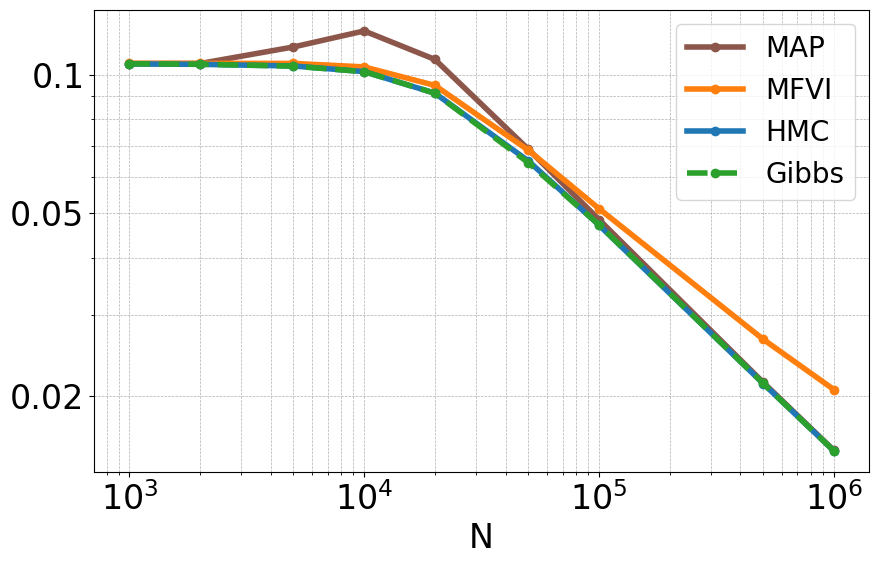

In [15]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np


sizes = [1000, 2000 ,5000, 10000, 20000, 50000, 100000, 500000, 1000000]

average_rmse_hmc = [0.10564655901765577,
 0.10542132156917491,
 0.10456250142874086,
 0.10163034957702455,
 0.09124758979340436,
 0.0649604271143221,
 0.04710005721240507,
 0.021292371624796854,
 0.015186997865457411]


average_rmse_vi = [0.10593707661705243,
 0.10595060088885326,
 0.10592231381236832,
 0.1040668383365188,
 0.09486547160560765,
 0.0685526664221704,
 0.05114671140016983,
 0.026576777792448734,
 0.020654313360086177]

average_rmse_map = [0.10585412070178038,
 0.10585412062085524,
 0.11501808122554828,
 0.1246448120245008,
 0.10805825311091984,
 0.068891183966794,
 0.048415311937879485,
 0.021413799904862613,
 0.015230376341345952]

#dolan = pd.read_csv('coverage-dolan.csv')
#gooby = pd.read_csv('coverage-gooby.csv')

#gibbs = pd.concat([dolan, gooby])

dolan = pd.read_csv('rmse-dolan.csv')
gooby = pd.read_csv('rmse-gooby.csv')
spurdo = pd.read_csv('rmse-spurdo.csv')
gibbs = pd.concat([dolan, gooby, spurdo])

gibbs = gibbs[gibbs['N']!=500]
gibbs = gibbs[gibbs['method']=='Gibbs']

gibbs_rmse = []
for VK, df in gibbs.groupby(['V','K']):
    #print(VK)
    #print(df['N'].value_counts())
    if VK == (100, 5):
        print('hey')
        gibbs_rmse = df.groupby('N')['RMSE'].apply(np.mean)
        
"""
dolan = pd.read_csv('laplace-dolan.csv')
gooby = pd.read_csv('laplace-gooby.csv')

laplace = pd.concat([dolan, gooby])

for VK, df in laplace.groupby(['V','K']):
    #print(VK)
    #print(df['N'].value_counts())
    if VK == (100, 5):
        print('hey')
        laplace_rmse = df.groupby('N')['RMSE'].apply(np.mean)
"""

plt.figure(figsize=(10, 6))

plt.plot(sizes, average_rmse_map, marker='o', label='MAP', color='tab:brown', linewidth=4)
plt.plot(sizes, average_rmse_vi, marker='o', label='MFVI', color='tab:orange', linewidth=4)
plt.plot(sizes, average_rmse_hmc, marker='o', label='HMC', color='tab:blue', linewidth=4)
if len(gibbs_rmse):
    rmse = np.array([None for i in sizes])
    rmse[0:len(gibbs_rmse)] = gibbs_rmse
    plt.plot(sizes, rmse, marker='o', label='Gibbs', color='tab:green', linewidth=4, linestyle = '--')

#if len(laplace_rmse):
#    rmse = np.array([None for i in sizes])
#    rmse[0:len(laplace_rmse)] = laplace_rmse
#    plt.plot(sizes, rmse, marker='o', label='Gibbs', color='tab:brown', linewidth=2)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('N', fontsize=24)
#plt.ylabel('RMSE', fontsize=22)
#plt.title('Comparison of RMSE for VI and HMC', fontsize=16)
plt.legend(fontsize=20)
plt.grid(True, which="both", linestyle='--', linewidth=0.5)

yticks = [0.02, 0.05, 0.1]
plt.yticks(yticks, [str(tick) for tick in yticks], fontsize=24)


#ytick_labels = [r'$2\times10^{-2}$', r'$5\times10^{-2}$', r'$1\times10^{-1}$']
#plt.yticks(yticks, ytick_labels, fontsize=20)
#plt.yticks(fontsize=13)
#plt.yticks([], [])
plt.xticks(fontsize=24)
plt.show()



In [5]:
1+1

2

In [66]:
gibbs['N'].value_counts()

N
500000     13
1000000    13
1000       12
2000       12
5000       12
10000      12
20000      12
50000      12
100000     12
2000000     3
500         1
Name: count, dtype: int64

In [77]:
gibbs

,V,K,N,RMSE,RMSE_normalized,no_of_datasets,method
0,100,5,1000,0.105719,0.998729,10,Gibbs
1,100,5,2000,0.105491,0.996573,10,Gibbs
2,100,5,5000,0.104457,0.986807,10,Gibbs
3,100,5,10000,0.101642,0.960208,10,Gibbs
4,100,5,20000,0.091190,0.861470,10,Gibbs
...,...,...,...,...,...,...,...
4,200,10,20000,0.077100,0.993911,6,Gibbs
5,200,10,50000,0.076099,0.981009,6,Gibbs
6,200,10,100000,0.071987,0.927999,6,Gibbs
7,200,10,500000,0.041831,0.539300,6,Gibbs


/tmp/ipykernel_2737573/1551666359.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis', lut=len(gibbs.groupby(['V', 'K'])))


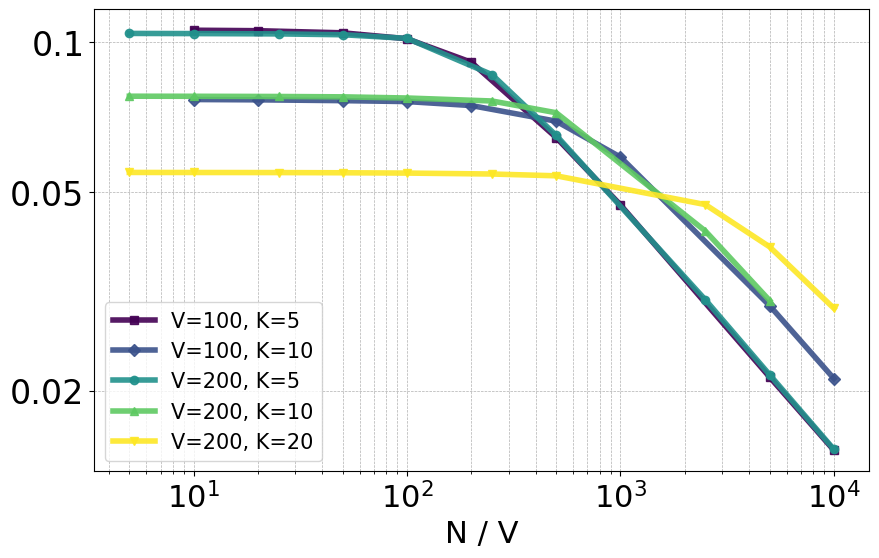

In [17]:
# per size
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np


dolan = pd.read_csv('rmse-dolan.csv')
gooby = pd.read_csv('rmse-gooby.csv')
spurdo = pd.read_csv('rmse-spurdo.csv')
gibbs = pd.concat([dolan, gooby, spurdo])

gibbs = gibbs[gibbs['N']!=500]
gibbs = gibbs[gibbs['method']=='Gibbs']

plt.figure(figsize=(10, 6))

cmap = cm.get_cmap('viridis', lut=len(gibbs.groupby(['V', 'K'])))
markers = [ 's', 'D','o', '^', 'v', 'P']
for idx,((V, K), df) in enumerate(gibbs.groupby(['V', 'K'])):
    # Compute N/V
    #x_values = df['N'] / V
    
    # Compute mean RMSE for each N
    gibbs_rmse = df.groupby('N')['RMSE'].mean()
    
    x_vals = list(gibbs_rmse.index)
    x_vals = [n/V for n in x_vals] 

    if (V,K)==(100,10): 
        x_vals = x_vals[:-1]
        gibbs_rmse = gibbs_rmse[:-1]

    color = cmap((idx)/ len(gibbs.groupby(['V', 'K'])))
    marker = markers[idx % len(markers)] 
    plt.loglog(x_vals, gibbs_rmse,  linestyle='-', label=f'V={V}, K={K}', alpha=0.90,linewidth=4.0, marker=marker, color=color) #, color=color

plt.xlabel('N / V', fontsize=22)
#plt.ylabel('RMSE', fontsize=14)
plt.legend(fontsize=15)
#plt.title('Log-log RMSE vs N/V for each (V,K)')
plt.grid(True, which="both", linestyle="--", linewidth=0.5)



import matplotlib.ticker as ticker 
ax = plt.gca()
# Set exactly these major ticks and remove any minor ticks.
ax.yaxis.set_major_locator(ticker.FixedLocator(yticks))
ax.yaxis.set_minor_locator(ticker.NullLocator())


plt.yticks([],[])
yticks = [0.02, 0.05, 0.1]
plt.yticks(yticks, [str(tick) for tick in yticks], fontsize=24)

#plt.yticks(fontsize=22)
plt.xticks(fontsize=22)
plt.show()

In [4]:
# laplace
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np

dolan = pd.read_csv('laplace-dolan.csv')
gooby = pd.read_csv('laplace-gooby.csv')

laplace = pd.concat([dolan, gooby])


for VK, df in laplace.groupby(['V','K']):
    print(VK)
    print(df['N'].value_counts())

(100, 5)
N
1000      1
2000      1
5000      1
10000     1
20000     1
50000     1
100000    1
Name: count, dtype: int64
(100, 10)
N
1000       1
2000       1
5000       1
10000      1
20000      1
50000      1
100000     1
500000     1
1000000    1
Name: count, dtype: int64
(100, 20)
N
1000       1
2000       1
5000       1
10000      1
20000      1
50000      1
100000     1
500000     1
1000000    1
Name: count, dtype: int64
(200, 5)
N
1000       1
2000       1
5000       1
10000      1
20000      1
50000      1
100000     1
500000     1
1000000    1
Name: count, dtype: int64
(200, 10)
N
1000     1
2000     1
5000     1
10000    1
20000    1
50000    1
Name: count, dtype: int64


In [5]:
laplace.head()

,K,V,N,map,coverage,RMSE,RMSE_normalized
0,5,200,1000,NaN,0.974927,0.104165,1.000000
1,5,200,2000,NaN,0.974673,0.104165,1.000000
2,5,200,5000,NaN,0.977773,0.104167,1.000023
3,5,200,10000,NaN,0.995333,0.118179,1.135016
4,5,200,20000,NaN,0.987470,0.131047,1.258804


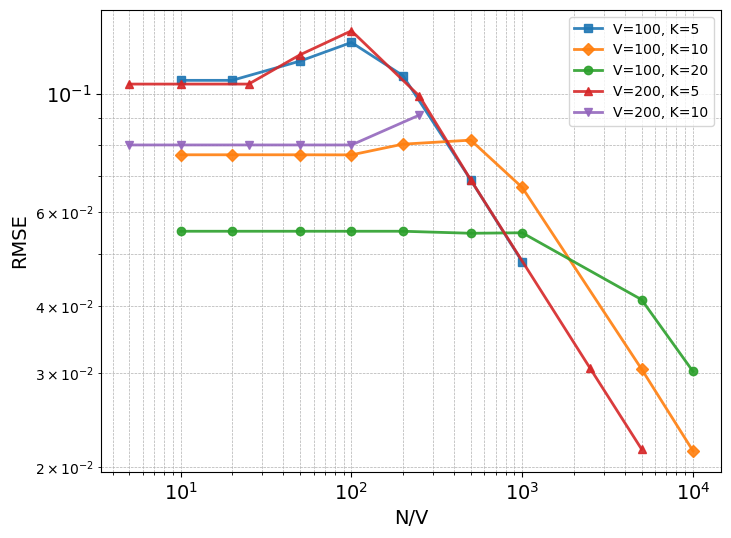

In [10]:
### LAPLACE
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np

dolan = pd.read_csv('laplace-dolan.csv')
gooby = pd.read_csv('laplace-gooby.csv')

laplace = pd.concat([dolan, gooby])

plt.figure(figsize=(8, 6))

markers = [ 's', 'D','o', '^', 'v', 'P']
for idx,((V, K), df) in enumerate(laplace.groupby(['V', 'K'])):
    # Compute N/V
    #x_values = df['N'] / V
    
    # Compute mean RMSE for each N
    laplace_rmse = df.groupby('N')['RMSE'].mean()
    if (V,K)==(200,10):
        dff = df
    x_vals = list(laplace_rmse.index)
    x_vals = [n/V for n in x_vals]


    color = cmap((idx)/ len(gibbs.groupby(['V', 'K'])))
    marker = markers[idx % len(markers)] 
    # Plot log-log
    plt.loglog(x_vals, laplace_rmse,  linestyle='-', label=f'V={V}, K={K}', alpha=0.90,linewidth=2.0, marker=marker) #, color=color

# Labels and legend
plt.xlabel('N/V', fontsize=14)
plt.ylabel('RMSE', fontsize=14)
plt.legend()
#plt.title('Log-log RMSE vs N/V for each (V,K)')
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
plt.show()

# zipf

In [4]:
1+1

2

In [5]:
# ZIPF
def calculate_rmse_per_size(data_dir, saved_fits_dir, inference_method, sizes, D):

    rmse_scores = {}

    for data_id in range(1, 11):
     
        data_path = os.path.join(data_dir, f"{data_id}-zipf.json")
        with open(data_path) as f:
            data = json.load(f)
        
        true_theta = np.array(data['theta'])
        vocabulary = data['vocabulary']

        for size in sizes:
            fit = load_fit_by_size(size, os.path.join(saved_fits_dir, str(data_id)+'-zipf'))

            if fit is None:
                continue

            if inference_method == 'hmc':
                estimated_word_vectors = fit['word_vectors']
                estimated_context_vectors = fit['context_vectors']
            elif inference_method == 'vi':
                estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_vi(fit.variational_sample_pd, vocabulary, D=D)
            elif inference_method in ('map', 'laplace'):
                estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_vi(fit.optimized_params_pd, vocabulary, D=D)
            elif inference_method == 'gibbs':
                filepath = os.path.join(saved_fits_dir, str(data_id), f'gibbs-samples-N-{size}.csv')
                estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_gibbs(filepath, vocabulary)

            num_samples = estimated_word_vectors.shape[2] if inference_method != 'map' else 1

            # Combine and reshape theta samples
            theta_combined = np.concatenate((estimated_word_vectors, estimated_context_vectors), axis=0)
            theta_samples = np.moveaxis(theta_combined, 2, 0)

            # Calculate RMSE
            rmse = calculate_rmse(theta_samples, true_theta, vocabulary)

            if size not in rmse_scores:
                rmse_scores[size] = []
            rmse_scores[size].append(rmse)

            #print(f"Dataset: {data_id}, Size: {size}, RMSE: {rmse}")

    return rmse_scores

def average_rmse_across_datasets(data_dir, base_dir, inference_method, sizes, D):
    rmse_scores_per_size = calculate_rmse_per_size(data_dir, base_dir, inference_method, sizes,D)
    average_rmse_scores = [np.mean(rmse_scores_per_size[size]) for size in sizes if size in rmse_scores_per_size]
    return average_rmse_scores


data_dir = "../../data/ten_V100K5-zipf"
base_dir = "../../results_ten_V100K5_zipf/nofix/hmc/"
inference_method = 'hmc'
sizes = [1000, 2000 ,5000, 10000, 20000, 50000, 100000, 500000, 1000000]
D = 5

average_rmse_hmc = average_rmse_across_datasets(data_dir, base_dir, inference_method, sizes,D)


In [3]:
import pandas as pd

gibbs =  pd.read_csv('rmse-spurdo-new.csv')

In [6]:
gibbs[gibbs['simulation']=='zipf'].head()

,V,K,N,simulation,RMSE,RMSE_normalized,no_of_datasets,method
20,100,5,1000,zipf,0.105702,0.998567,10,Gibbs
21,100,5,2000,zipf,0.105456,0.996237,10,Gibbs
22,100,5,5000,zipf,0.104606,0.988208,10,Gibbs
23,100,5,10000,zipf,0.102253,0.965982,10,Gibbs
24,100,5,20000,zipf,0.095991,0.906827,10,Gibbs


hey


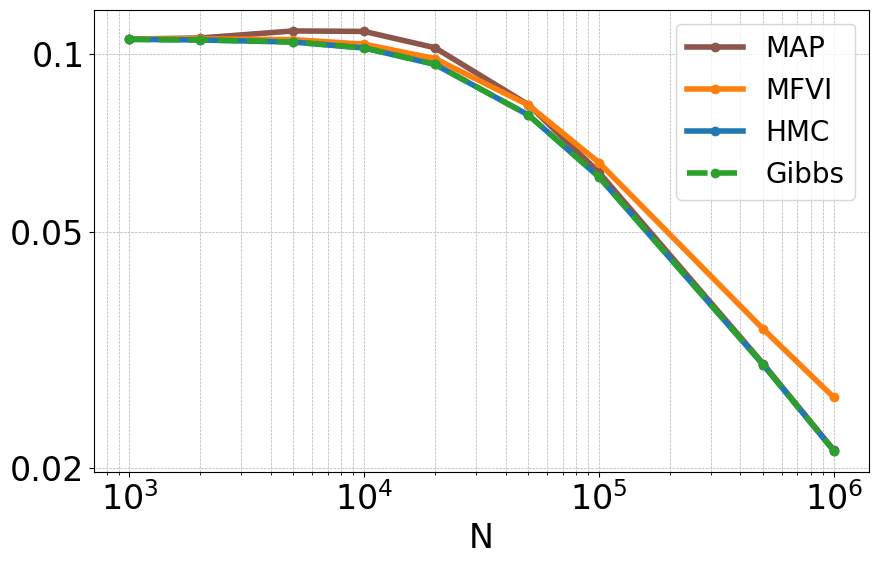

In [13]:
### -- ZIPF ---
import matplotlib.ticker as ticker 
sizes = [1000, 2000 ,5000, 10000, 20000, 50000, 100000, 500000, 1000000]
average_rmse_hmc = [0.10566962391395437,
 0.10543560923792547,
 0.104577305522908,
 0.10217997153176131,
 0.09590059677201633,
 0.07882376469696882,
 0.06193224009779673,
 0.02989329434816066,
 0.021403230747847904]

average_rmse_vi = [0.10595903455947564,
 0.10588004121374635,
 0.1055824135075639,
 0.10370684428802486,
 0.09808070219091836,
 0.08191959084013638,
 0.06551563365743465,
 0.03434167266968659,
 0.026339152488510896]

average_rmse_map = [0.10580674565989281,
 0.10623631982716468,
 0.10919945392278929,
 0.10898558538450745,
 0.10232477358904564,
 0.08203042591249907,
 0.06307238698413173,
 0.030024078377715056,
 0.021461286447834075]


gibbs =  pd.read_csv('rmse-spurdo-new.csv')
gibbs = gibbs[gibbs['simulation']=='zipf']
gibbs_rmse = []
for VK, df in gibbs.groupby(['V','K']):
    #print(VK)
    #print(df['N'].value_counts())
    if VK == (100, 5):
        print('hey')
        gibbs_rmse = df.groupby('N')['RMSE'].apply(np.mean)
        
"""
dolan = pd.read_csv('laplace-dolan.csv')
gooby = pd.read_csv('laplace-gooby.csv')

laplace = pd.concat([dolan, gooby])

for VK, df in laplace.groupby(['V','K']):
    #print(VK)
    #print(df['N'].value_counts())
    if VK == (100, 5):
        print('hey')
        laplace_rmse = df.groupby('N')['RMSE'].apply(np.mean)
"""

plt.figure(figsize=(10, 6))

plt.plot(sizes, average_rmse_map, marker='o', label='MAP', color='tab:brown', linewidth=4)
plt.plot(sizes, average_rmse_vi, marker='o', label='MFVI', color='tab:orange', linewidth=4)
plt.plot(sizes, average_rmse_hmc, marker='o', label='HMC', color='tab:blue', linewidth=4)
if len(gibbs_rmse):
    rmse = np.array([None for i in sizes])
    rmse[0:len(gibbs_rmse)] = gibbs_rmse
    plt.plot(sizes, rmse, marker='o', label='Gibbs', color='tab:green', linewidth=4, linestyle = '--')

#if len(laplace_rmse):
#    rmse = np.array([None for i in sizes])
#    rmse[0:len(laplace_rmse)] = laplace_rmse
#    plt.plot(sizes, rmse, marker='o', label='Gibbs', color='tab:brown', linewidth=2)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('N', fontsize=24)
#plt.ylabel('RMSE', fontsize=22)
#plt.title('Comparison of RMSE for VI and HMC', fontsize=16)
plt.legend(fontsize=20)
plt.grid(True, which="both", linestyle='--', linewidth=0.5)

yticks = [0.02, 0.05, 0.1]
plt.yticks(yticks, [str(tick) for tick in yticks], fontsize=24)


ax = plt.gca()

# Set exactly these major ticks and remove any minor ticks.
ax.yaxis.set_major_locator(ticker.FixedLocator(yticks))
ax.yaxis.set_minor_locator(ticker.NullLocator())

#ytick_labels = [r'$2\times10^{-2}$', r'$5\times10^{-2}$', r'$1\times10^{-1}$']
#plt.yticks(yticks, ytick_labels, fontsize=20)
#plt.yticks(fontsize=13)
#plt.yticks([], [])
plt.xticks(fontsize=24)
plt.show()

In [8]:
data_dir = "../../data/ten_V100K5-zipf"
base_dir = "../../results_ten_V100K5_zipf/nofix/vi/"
inference_method = 'vi'
sizes = [1000, 2000 ,5000, 10000, 20000, 50000, 100000, 500000, 1000000]
D = 5

average_rmse_vi = average_rmse_across_datasets(data_dir, base_dir, inference_method, sizes,D)

In [13]:
data_dir = "../../data/ten_V100K5-zipf"
base_dir = "../../results_ten_V100K5_zipf/nofix/map/"
inference_method = 'map'
sizes = [1000, 2000 ,5000, 10000, 20000, 50000, 100000, 500000, 1000000]
D = 5

average_rmse_map = average_rmse_across_datasets(data_dir, base_dir, inference_method, sizes,D)

In [15]:
X = pd.read_csv('coverage-zipf.csv')

In [16]:
X.head()

,dataset_ix,N,K,V,ci-90-coverage,RMSE,RMSE_normalized
0,1,1000,5,100,0.8973,0.105701,0.998560
1,2,1000,5,100,0.8981,0.105742,0.998945
2,3,1000,5,100,0.8956,0.105655,0.998123
3,4,1000,5,100,0.8953,0.105750,0.999015
4,5,1000,5,100,0.8988,0.105768,0.999190


In [ ]:
import pandas as pd
import numpy as np

dolan = pd.read_csv('laplace-dolan.csv')
gooby = pd.read_csv('laplace-gooby.csv')

laplace = pd.concat([dolan, gooby])


for VK, df in laplace.groupby(['V','K']):
    print(VK)
    print(df['N'].value_counts())

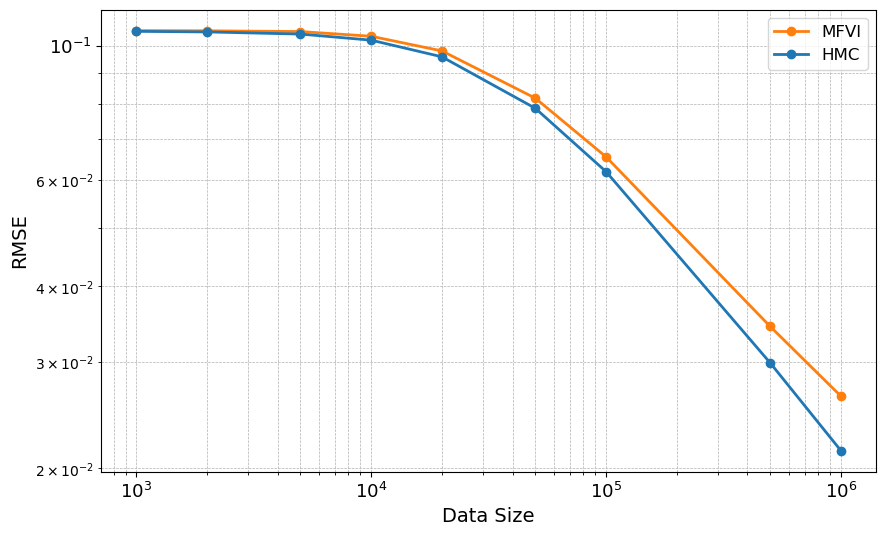

In [13]:

def plot_comparison_rmse(sizes, average_rmse_vi, average_rmse_hmc, gibbs_rmse=[]):
    """
    Plot the average RMSE scores for VI and HMC on a log-log scale.

    Args:
        sizes (list): List of sizes for which RMSE was calculated.
        average_rmse_vi (list): Average RMSE scores for VI.
        average_rmse_hmc (list): Average RMSE scores for HMC.
    """
    plt.figure(figsize=(10, 6))
    plt.plot(sizes, average_rmse_vi, marker='o', label='MFVI', color='tab:orange', linewidth=2)
    plt.plot(sizes, average_rmse_hmc, marker='o', label='HMC', color='tab:blue', linewidth=2)
    if len(gibbs_rmse):
        rmse = np.array([None for i in sizes])
        rmse[0:len(gibbs_rmse)] = gibbs_rmse
        plt.plot(sizes, rmse, marker='o', label='Gibbs', color='tab:green', linewidth=2,  linestyle='--')

    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Data Size', fontsize=14)
    plt.ylabel('RMSE', fontsize=14)
    #plt.title('Comparison of RMSE for VI and HMC', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, which="both", linestyle='--', linewidth=0.5)
    plt.yticks(fontsize=13)
    plt.xticks(fontsize=13)
    plt.show()

plot_comparison_rmse(sizes, average_rmse_vi, average_rmse_hmc)